# Fase 0: Pipeline CSI: cargar, visualizar, limpiar y clasificar datos para entrenar el modelo

Pipeline completo end-to-end sobre CSI:

1. **Cargar** CSI (por ahora sintético; luego datos reales del ESP32).
2. **Visualizar** amplitud y fase de una ventana quieto vs movimiento.
3. **Limpiar** y extraer características.
4. **Clasificar** movimiento vs quieto y medir.
5. **Validar** que el pipeline se degrada con la SNR.

In [ ]:
import sys, os
# Localiza src/ tanto si el notebook se lanza desde notebooks/ como desde la raíz.
for _p in ('../src', 'src', '../../src'): 
    _ap = os.path.abspath(_p)
    if os.path.isdir(_ap):
        sys.path.insert(0, _ap); break

import numpy as np
import matplotlib.pyplot as plt

from synth_csi import make_dataset, generate_window, N_SUBCARRIERS
from features import to_amplitude, clean_amplitude, extract_features, FEATURE_NAMES

print('Subportadoras:', N_SUBCARRIERS) 

Subportadoras: 64
El WiFi no transmite en una sola frecuencia, sino repartido en muchas **subportadoras**: frecuencias vecinas dentro del canal que van en paralelo (esto es OFDM). En 802.11n con 20 MHz hay ~64. Para el sensing, cada subportadora es un **"sensor" independiente en frecuencia**. El CSI nos dice cómo el canal afectó a cada una, así que tenemos un **vector de ~64 valores** en vez de un solo número (el RSSI, que es solo la potencia total


### ¿Por qué 64 subportadoras?

El WiFi no transmite en una sola frecuencia, sino repartido en muchas
**subportadoras**: frecuencias vecinas dentro del canal que van en paralelo
(esto es OFDM). En 802.11n con 20 MHz hay ~64.

Para el sensing, cada subportadora es un **"sensor" independiente en frecuencia**.
El CSI nos dice cómo el canal afectó a cada una, así que tenemos un **vector de
~64 valores** en vez de un solo número (el RSSI, que es solo la potencia total).

¿Por qué importa? Cuando alguien se mueve, la señal rebota (**multipath**) y eso
afecta a **cada frecuencia de forma distinta**: unas subportadoras suben de
amplitud y otras bajan. Con 64 vemos la "forma" de esa deformación y cómo cambia
en el tiempo. Ahí está la señal que separa **movimiento** de **quieto**.


## 1. Cargar CSI

Generamos un dataset de ventanas etiquetadas. Cada ventana es una matriz
compleja `(n_paquetes, n_subportadoras)`, el mismo formato que reporta el
ESP32-CSI-Tool.

In [ ]:
X, y = make_dataset(n_per_class=200, snr_db=25, seed=0) # Creamos el dataset sintético con 200 ventanas por clase y SNR de 25 dB
print('X (ventanas, paquetes, subportadoras):', X.shape, X.dtype)
print('y:', y.shape, '| clases [quieto, movim]:', np.bincount(y))

X (ventanas, paquetes, subportadoras): (400, 128, 64) complex128
y: (400,) | clases [quieto, movim]: [200 200]


## 2. Visualizar amplitud y fase

Comparamos una ventana **quieta** y una con **movimiento**. En quieto la
amplitud es casi constante en el tiempo (bandas horizontales limpias); con
movimiento aparecen fluctuaciones temporales.

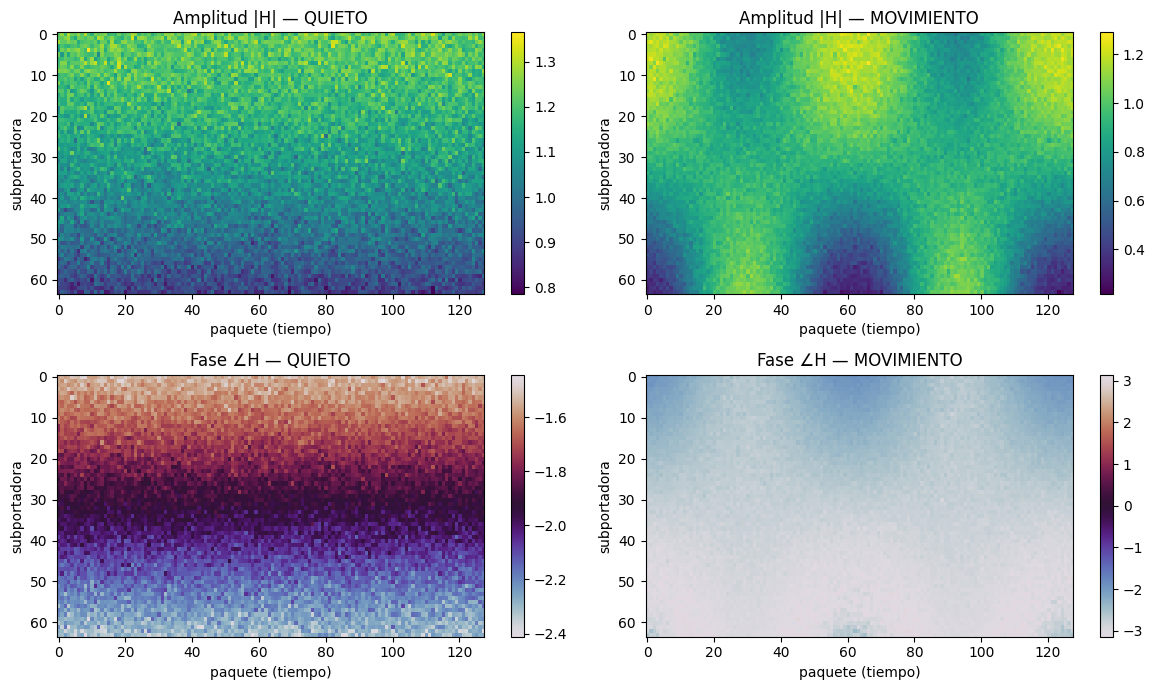

In [4]:
rng = np.random.default_rng(1)
w_quieto = generate_window(0, rng=rng)
w_movim  = generate_window(1, rng=rng)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for col, (w, ttl) in enumerate([(w_quieto, 'QUIETO'), (w_movim, 'MOVIMIENTO')]):
    im0 = axes[0, col].imshow(np.abs(w).T, aspect='auto', cmap='viridis')
    axes[0, col].set_title(f'Amplitud |H| — {ttl}')
    axes[0, col].set_xlabel('paquete (tiempo)'); axes[0, col].set_ylabel('subportadora')
    fig.colorbar(im0, ax=axes[0, col])
    im1 = axes[1, col].imshow(np.angle(w).T, aspect='auto', cmap='twilight')
    axes[1, col].set_title(f'Fase ∠H — {ttl}')
    axes[1, col].set_xlabel('paquete (tiempo)'); axes[1, col].set_ylabel('subportadora')
    fig.colorbar(im1, ax=axes[1, col])
plt.tight_layout(); plt.show()

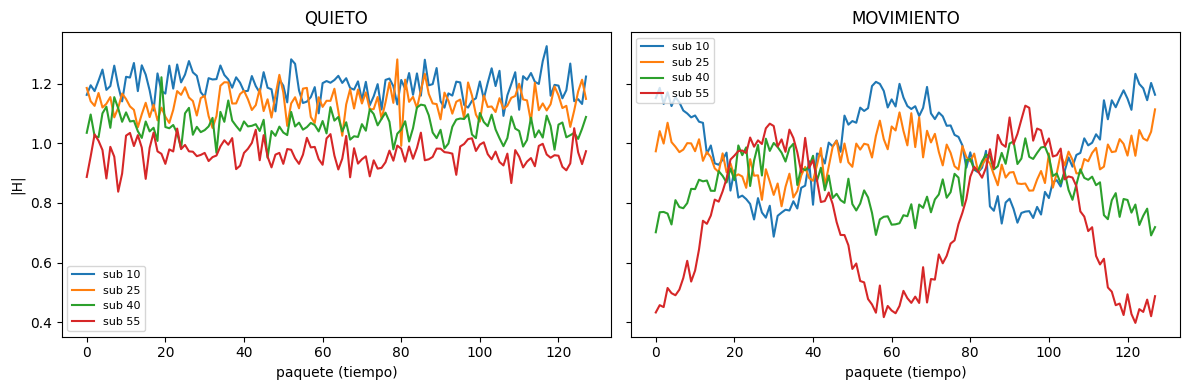

In [5]:
# Amplitud de unas pocas subportadoras a lo largo del tiempo.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (w, ttl) in zip(axes, [(w_quieto, 'QUIETO'), (w_movim, 'MOVIMIENTO')]):
    amp = np.abs(w)
    for sc in [10, 25, 40, 55]:
        ax.plot(amp[:, sc], label=f'sub {sc}')
    ax.set_title(ttl); ax.set_xlabel('paquete (tiempo)'); ax.legend(fontsize=8)
axes[0].set_ylabel('|H|')
plt.tight_layout(); plt.show()

## 3. Limpiar y extraer características

`clean_amplitude` convierte la amplitud en **fluctuación relativa** respecto
al nivel estático (quita la geometría fija de la sala, conserva el movimiento).
Luego resumimos cada ventana en 8 características.

In [6]:
F = extract_features(X)
print('Features:', F.shape)
print('\nMedia por clase:')
print(f"{'feature':15s}  quieto   movim")
for i, name in enumerate(FEATURE_NAMES): # Media de cada feature por clase
    print(f'{name:15s} {F[y==0][:,i].mean():7.3f} {F[y==1][:,i].mean():7.3f}')

Features: (400, 8)

Media por clase:
feature          quieto   movim
tstd_mean         0.044   0.103
tstd_max          0.078   0.234
tstd_std          0.012   0.055
diff_mean         0.050   0.049
diff_max          0.091   0.074
lag1_autocorr    -0.008   0.551
amp_mean          1.128   1.307
amp_std           0.173   0.218


## 4. Clasificar movimiento vs quieto

              precision    recall  f1-score   support

      quieto       1.00      1.00      1.00        60
  movimiento       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



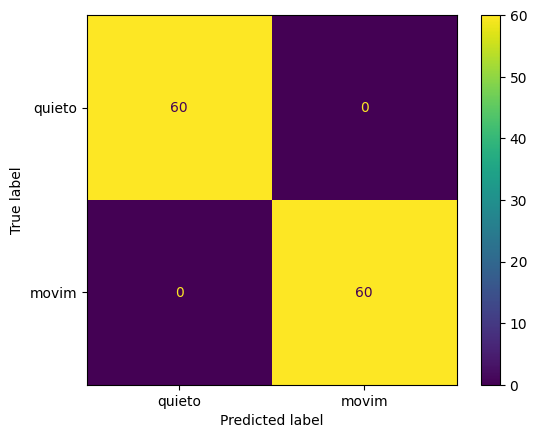

In [7]:
from sklearn.ensemble import RandomForestClassifier # Usamos Random Forest como clasificador
from sklearn.model_selection import train_test_split # Para separar el dataset en entrenamiento y test
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X_tr, X_te, y_tr, y_te = train_test_split(F, y, test_size=0.3, stratify=y, random_state=0) # Separación en entrenamiento y test 
clf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=0))
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred, target_names=['quieto', 'movimiento']))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=['quieto','movim']); plt.show()

## 5. Validación:

Un pipeline honesto debe **degradarse** al bajar la SNR y acercarse al azar
(0.5) cuando la señal se ahoga en ruido. Si diera 100% siempre, sospecharíamos
fuga de datos.

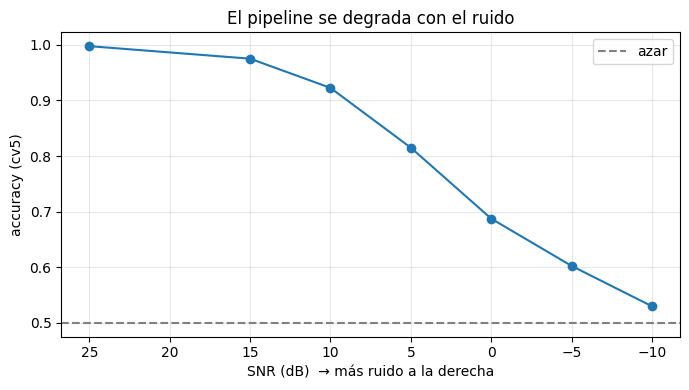

In [8]:
from sklearn.model_selection import cross_val_score # Para hacer cross-validation y ver cómo se degrada el pipeline con el ruido
snrs = [25, 15, 10, 5, 0, -5, -10] # SNRs a probar
accs = []
for snr in snrs: # Para cada SNR, generamos un dataset y evaluamos el pipeline con cross-validation
    Xs, ys = make_dataset(n_per_class=200, snr_db=snr, seed=0)
    Fs = extract_features(Xs)
    pipe = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=150, random_state=0))
    accs.append(cross_val_score(pipe, Fs, ys, cv=5).mean())

plt.figure(figsize=(7,4))
plt.plot(snrs, accs, 'o-')
plt.axhline(0.5, ls='--', c='gray', label='azar')
plt.gca().invert_xaxis()
plt.xlabel('SNR (dB)  → más ruido a la derecha'); plt.ylabel('accuracy (cv5)')
plt.title('El pipeline se degrada con el ruido'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Conclusión

Pipeline de Fase 0 completo y validado: **cargar → visualizar → limpiar →
features → clasificar → validar**. Todo el código reutilizable (loader,
limpieza, features, entrenamiento) queda en `src/` listo para alimentarse con
**datos reales del ESP32** en la Fase 1 sin reescribir nada.